# Set-up

## Load libraires

In [ ]:
#Set directory
# install.packages("here", repos= "https://cloud.r-project.org")
library(here)
setwd(here())
#Install and load libraires
source("./src/libraries.r")
install_packages("./requirements.txt")
source("./src/load_libraries.r")

Warning message:
"le package 'reshape2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"le package 'DescTools' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'mice' a été compilé avec la version R 4.2.3"
Warning message in check_dep_version():
"ABI version mismatch: 
lme4 was built with Matrix ABI version 1
Current Matrix ABI version is 0
Please re-install lme4 from source or restore original 'Matrix' package"

Attachement du package : 'mice'


L'objet suivant est masqué depuis 'package:stats':

    filter


Les objets suivants sont masqués depuis 'package:base':

    cbind, rbind


Warning message:


In [2]:
# Functions
invisible(lapply(list.files("./src/descriptive_stats", full.names = TRUE), source))
invisible(lapply(list.files("./src/models", full.names = TRUE), source))

Warning message:
"le package 'pROC' a été compilé avec la version R 4.2.3"
Type 'citation("pROC")' for a citation.


Attachement du package : 'pROC'


Les objets suivants sont masqués depuis 'package:stats':

    cov, smooth, var


Warning message:
"le package 'ResourceSelection' a été compilé avec la version R 4.2.3"
ResourceSelection 0.3-6 	 2023-06-27


Attachement du package : 'survival'


L'objet suivant est masqué depuis 'package:caret':

    cluster


Warning message:
"le package 'survminer' a été compilé avec la version R 4.2.3"

Attachement du package : 'survminer'


L'objet suivant est masqué depuis 'package:survival':

    myeloma


L'objet suivant est masqué depuis 'package:lava':

    %++%




## Load dataset

In [ ]:
data <- read_sav("./data/Torres_bd_vf.sav")
data <- data %>%
  mutate(across(where(~ inherits(.x, "haven_labelled")), ~ as.factor(.x)))
#Per protocol population
data<-data[data$PP==1,]

# Data exploration

## Load and treat dataset

In [4]:
#Characteristics of dataset
torres_caracs=characteristics(data[, !sapply(data, inherits, what = "Date")])
#Correction
data[["daysinICU"]]=as.numeric(data$EvolUCIFechaAlta-data$EvolUCIFechaIngr)+1
check_dias_uci <- with(data, 
  ((is.na(EvolDiasUCI)| EvolDiasUCI==0) & is.na(EvolUCIFechaAlta) & is.na(EvolUCIFechaIngr)) |
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr)+1)|
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr))
)
# EvolDiasUCI vs EvolIUCI 
check_iuci <- with(data,
  EvolUCI == 0 | !is.na(EvolDiasUCI)
)
invalid <- which(!check_dias_uci %in% TRUE)  # selects only FALSE (excludes NA)
data$EvolDiasUCI[invalid] <- data$daysinICU[invalid]
data[!check_dias_uci,c("EvolDiasUCI","daysinICU","EvolUCIFechaIngr","EvolUCIFechaAlta")]
#Create variables
#Year of admission
data$YearOfAdmission <- as.factor(format(as.Date(data$FechaIngr), "%Y"))
#Ratio Pao2/FiO2
data$RatioPao2_oxygen <- data$GpO201/(data$GFiO201/100)
#Macrolide therapy
abx_vars <- paste0("TAntibiotico", 1:12)
macrolides <- c("azitromicina", "claritromicina", "eritromicina")
data$macrolide <- factor(
  apply(data[abx_vars], 1, function(row) any(row %in% macrolides, na.rm = TRUE)),
  levels = c(FALSE, TRUE),
  labels = c(0, 1)
)
data <- data %>%
  mutate(TimeToFirstAntibiotic_SS = case_when(
    TTiempoDesdeLlegUCIAS <= 1 & CdxShockSept == 1 ~ "0",
    TTiempoDesdeLlegUCIAS <= 4 & CdxShockSept == 0 ~ "1",
    TRUE ~ NA_character_  # For all other cases
  )) %>%
  mutate(TimeToFirstAntibiotic_SS = as.factor(TimeToFirstAntibiotic_SS))
  #Oder by patient ids
data <- data[order(data$IdPac), ]

#Select variables of interest
vars_dint <- c("IdPac","YearOfAdmission","Edad",
"Sexo",
"Fumador",
"Diabetes",
"EPOC",
"HTA",
"Cancer",
"CardIsq",
"CFiebre",
"CAlterNivelConc",
"CDisnea",
"CTos",
"CEscalofrios",
"CDolorPleur",
"FINE",
"Puntos",
"CdxVM",
"CdxVMtipo",
"CdxShockSept",
"CdxPAP90",
"CdxMultilobar",
"CdxPaFi250",
"RatioPao2_oxygen",
"UCI_Interm",
"TimeToFirstAntibiotic_SS",
"macrolide",
"BGlucosa",
"BCreatinina",
"HPlaquetas",
"HLeucocitos",
"BProteinasTot",
"PCT1",
"IL61",
"IL81",
"IL101",
"Temperatura",
"FR",
"FC",
"EarlyFailure",
"EMV",
"ESS",
"ED",
"LateFailure",
"RP",
"RF",
"LMV",
"LSS",
"tiempo_estancia",
"EvolDiasUCI",
"EvolMort28",
"EstabClin",
"Dia_TF",
"Grupo",
"ITT",
"PP",
"Centro"
)


EvolDiasUCI,daysinICU,EvolUCIFechaIngr,EvolUCIFechaAlta
<dbl>,<dbl>,<date>,<date>
11,11,2004-09-10,2004-09-20
5,5,2004-12-07,2004-12-11
35,35,2005-03-15,2005-04-18
NA,NA,NA,NA
16,16,2006-03-28,2006-04-12
63,63,2006-04-20,2006-06-21
9,9,2006-12-28,2007-01-05
10,10,2007-03-07,2007-03-16
10,10,2007-10-23,2007-11-01


In [5]:
#Convert data type
data_dint<-data[,vars_dint] %>%
  mutate(FINE=as.factor(FINE))%>%
  mutate(BProteinasTot =as.numeric(as.character(BProteinasTot)))%>%
  mutate(PCT1 =as.numeric(as.character(PCT1 )))%>%
  mutate(IL61 =as.numeric(as.character(IL61 )))%>%
  mutate(IL81 =as.numeric(as.character(IL81 )))%>%
  mutate(IL101 =as.numeric(as.character(IL101)))
data_dint[["ratio_il6_il10"]]=data_dint$IL101/data_dint$IL61
#Manually builds early and late failure
data_dint$EarlyFailureMan <- with(data_dint, factor(as.integer(EMV == 1 | ESS == 1 | ED == 1), levels = c(0,1)))
data_dint$LateFailureMan <- with(data_dint, factor(as.integer(LMV == 1 | LSS == 1 | RP == 1 | RF == 1), levels = c(0,1)))
data_dint$TreatmentFailureMan <- with(data_dint, factor(as.integer(EarlyFailureMan == 1 | LateFailureMan == 1), levels = c(0,1)))
# #Suppress
#data_dint <- data_dint %>% select(-TreatmentFailure, -LateFailure, -EarlyFailure)
#Compute pleural effusion
data$pleural_effusion <- with(data, factor(as.integer(!is.na(LPGlu) | !is.na(LPProt)| !is.na(LPLDH)| 
!is.na(LPCelulas)| !is.na(LPPM)), levels = c(0,1))) 
# table(data$Cancer,data$Grupo) 
caracs_dint<-characteristics(data_dint)
caracs_dint

variable,types,nombre_de_modalites,number_of_missing_values,proportion_missing_values_percent,moyenne,maximum,minimum,mode,proportion_mode_percent
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
IdPac,numeric,91,0,0.0,48.31250,301.0000,1.0,20,1.786
YearOfAdmission,factor,9,0,0.0,NA,NA,NA,3,0.000
Edad,numeric,57,0,0.0,64.97321,96.0000,19.0,81,7.143
Sexo,factor,2,0,0.0,NA,NA,NA,2,0.000
Fumador,factor,3,0,0.0,NA,NA,NA,3,0.000
Diabetes,factor,2,0,0.0,NA,NA,NA,1,18.750
EPOC,factor,2,0,0.0,NA,NA,NA,1,15.179
HTA,factor,2,0,0.0,NA,NA,NA,1,38.393
Cancer,factor,2,0,0.0,NA,NA,NA,1,9.821


Missing informations for temperature, respiratory and heart rates mostly

,IdPac,YearOfAdmission,Edad,Sexo,Fumador,Diabetes,EPOC,HTA,Cancer,CardIsq,⋯,IL81,EstabClin,EvolDiasUCI,FC,FR,Temperatura,TimeToFirstAntibiotic_SS,BProteinasTot,Dia_TF,
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,0,1
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,1,1
19,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,0,2
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,1,0,2
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,1,2
14,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,3
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,1,0,0,3
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,1,0,1,4
5,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,0,0,0,6


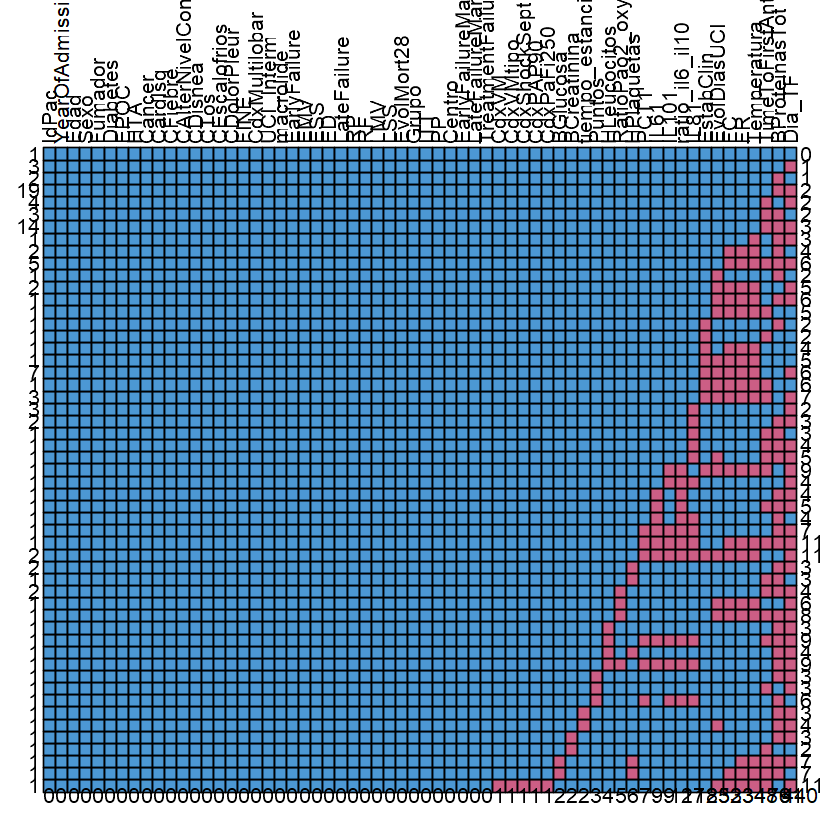

In [6]:
md.pattern(data_dint, rotate.names = TRUE)

Let's suppose MAR

## Per protocol

### Descriptive statistics

In [7]:
#Test normality of numerical variables
normality <- sapply(data_dint[!names(data_dint) %in% "IdPac"],seek_normality)
data.frame(variable = names(normality), normality = normality)

,variable,normality
,<chr>,<chr>
YearOfAdmission,YearOfAdmission,NA
Edad,Edad,not normal
Sexo,Sexo,NA
Fumador,Fumador,NA
Diabetes,Diabetes,NA
EPOC,EPOC,NA
HTA,HTA,NA
Cancer,Cancer,NA
CardIsq,CardIsq,NA


In [8]:
#Explicit modalities of categorical variables
data_dint_explcit<-data_dint %>%
  mutate(Sexo = recode(Sexo, "1" = "Male", "0" = "Female")) %>%
  mutate(Diabetes = recode(Diabetes, "1" = "Diabetes mellitus", "0" = "Not diabetic"))%>%
  mutate(Fumador = recode(Fumador, "1" = "Current smoker", "0" = "Not smoker"))%>%
  mutate(EPOC = recode(EPOC, "1" = "Chronic pulmonary disease", "0" = "Not EPOC"))%>%
  mutate(HTA = recode(HTA, "1" = "Congestive heart failure", "0" = "Not HTA"))%>%
  mutate(Cancer = recode(Cancer, "1" = "History of malignancy", "0" = "No cancer"))%>%
  mutate(CardIsq = recode(CardIsq, "1" = "Ischemic heart disease", "0" = "No IHD"))%>%
  mutate(CFiebre = recode(CFiebre, "1" = "Fever", "0" = "No fever"))%>%
  mutate(CAlterNivelConc = recode(CAlterNivelConc, "1" = "Altered Mental status", "0" = "Not altered"))%>%
  mutate(CDisnea = recode(CDisnea, "1" = "Breathlessness", "0" = "No Breathlessness"))%>%
  mutate(CTos = recode(CTos, "1" = "Cough", "0" = "No cough"))%>%
  mutate(CEscalofrios = recode(CEscalofrios, "1" = "Chills", "0" = "No chills"))%>%
  mutate(CDolorPleur = recode(CDolorPleur, "1" = "Chest pain", "0" = "No chest pain"))%>%
  mutate(CdxVM = recode(CdxVM, "1" = "Mechanical ventialtion", "0" = "No MV"))%>%
  mutate(CdxVMtipo = recode(CdxVMtipo, "1" = "Noninvasive alone","2" = "Noninvasive followed by invasive","3" = "Invasive alone", "0" = "No MV"))%>%
  mutate(CdxShockSept = recode(CdxShockSept, "1" = "Septic shock", "0" = "No shock"))%>%
  mutate(CdxPAP90 = recode(CdxPAP90, "1" = "Systolic blood pressure< 90 mmHg", "0" = "PAP>90"))%>%
  mutate(CdxMultilobar = recode(CdxMultilobar, "1" = "Multilobar involvement", "0" = "No involvement"))%>%
  mutate(CdxPaFi250 = recode(CdxPaFi250, "1" = "Ratio of PaO2 to fraction of inspired oxygen < 250 mmHg", "0" = "Ratio>250"))%>%
  mutate(UCI_Interm = recode(UCI_Interm, "1" = "ICU admission", "0" = "No ICU admission"))%>%
  mutate(TimeToFirstAntibiotic_SS = recode(TimeToFirstAntibiotic_SS, "1" = "Within 1h in patients with septic shock", "0" = "Within 4h in patients without septic shock"))%>% 
  mutate(macrolide = recode(macrolide, "1" = " Macrolide combination therapy", "0" = "No macrolide"))%>%
  mutate(EarlyFailureMan = recode(EarlyFailureMan, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EMV = recode(EMV, "1" = "Early mechanical ventilation", "0" = "EVM"))%>%
  mutate(ESS = recode(ESS, "1" = "Early septic shock", "0" = "no ESS"))%>%
  mutate(ED = recode(ED, "1" = "Early death", "0" = "no ED"))%>%
  mutate(LateFailureMan = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(RP = recode(RP, "1" = "Radiographic progression", "0" = "no RP"))%>%
  mutate(RF = recode(RF, "1" = "Respiratory failure", "0" = "no RF"))%>%
  mutate(LMV = recode(LMV, "1" = "Late mechanical ventilation", "0" = "no LMV"))%>%
  mutate(LSS = recode(LSS, "1" = "Late septic shock", "0" = "no LSS"))%>%
  mutate(EvolMort28 = recode(EvolMort28, "1" = "In-hospitality mortality", "0" = "no IHM"))%>%
  mutate(TreatmentFailureMan = recode(TreatmentFailureMan, "1" = "Treatment failure", "0" = "No treatment failure"))
#Summary of categorical variables
summary_cat_by_group(data_dint_explcit, "Grupo")

Variable,Category,Overall_N_prop,0_N_prop,1_N_prop
<chr>,<chr>,<chr>,<chr>,<chr>
YearOfAdmission,2004,8 (7.1%),5 (8.8%),3 (5.5%)
YearOfAdmission,2005,20 (17.9%),12 (21.1%),8 (14.5%)
YearOfAdmission,2006,21 (18.8%),8 (14%),13 (23.6%)
YearOfAdmission,2007,17 (15.2%),7 (12.3%),10 (18.2%)
YearOfAdmission,2008,14 (12.5%),7 (12.3%),7 (12.7%)
YearOfAdmission,2009,9 (8%),6 (10.5%),3 (5.5%)
YearOfAdmission,2010,10 (8.9%),6 (10.5%),4 (7.3%)
YearOfAdmission,2011,11 (9.8%),5 (8.8%),6 (10.9%)
YearOfAdmission,2012,2 (1.8%),1 (1.8%),1 (1.8%)


In [9]:
# Summary of numerical variables 
summary_num_by_group(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Variable,Overall_mean_SD,Overall_med_IQR,Overall_min_max,0_mean_SD,0_med_IQR,0_min_max,1_mean_SD,1_med_IQR,1_min_max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Edad,65.0 (19.7),69.0 (53.0 - 81.0),19.0 - 96.0,66.3 (19.8),70.0 (56.0 - 81.0),19.0 - 96.0,63.6 (19.6),68.0 (51.5 - 81.0),24.0 - 89.0
Puntos,107.1 (35.9),109.0 (85.0 - 135.0),4.0 - 173.0,109.0 (34.6),110.0 (88.5 - 133.5),4.0 - 173.0,105.1 (37.4),107.0 (81.2 - 134.8),28.0 - 168.0
RatioPao2_oxygen,234.5 (80.8),238.1 (179.6 - 278.6),63.6 - 609.5,230.2 (83.8),228.6 (171.0 - 292.6),76.0 - 407.5,239.2 (78.1),242.4 (217.7 - 267.4),63.6 - 609.5
BGlucosa,147.6 (64.0),131.0 (106.0 - 169.8),50.0 - 422.0,151.4 (66.7),129.0 (106.5 - 181.0),50.0 - 394.8,143.8 (61.6),136.0 (105.0 - 159.0),64.0 - 422.0
BCreatinina,1.6 (0.9),1.3 (1.0 - 1.7),0.4 - 5.2,1.6 (1.0),1.3 (1.0 - 1.8),0.4 - 5.2,1.5 (0.9),1.3 (0.9 - 1.7),0.6 - 4.9
HPlaquetas,250.4 (133.5),216.0 (176.2 - 283.0),32.0 - 864.0,265.2 (151.1),221.0 (181.0 - 283.0),105.0 - 864.0,234.4 (110.8),214.0 (175.5 - 277.0),32.0 - 630.0
HLeucocitos,15.4 (11.0),13.4 (9.0 - 21.2),1.3 - 74.0,15.2 (8.9),14.4 (9.3 - 23.1),1.4 - 36.7,15.6 (12.8),12.9 (8.4 - 17.8),1.3 - 74.0
BProteinasTot,26.5 (24.1),8.1 (6.3 - 55.5),4.9 - 64.0,24.5 (23.4),8.2 (6.7 - 49.5),5.2 - 58.0,28.1 (25.1),8.1 (6.1 - 55.8),4.9 - 64.0
PCT1,6.1 (11.6),1.8 (0.5 - 6.9),0.0 - 86.3,6.1 (7.7),3.0 (0.7 - 8.7),0.1 - 37.4,6.1 (14.6),1.2 (0.4 - 4.4),0.0 - 86.3


### Comparison tests

In [10]:
compare_var_cat(data_dint[!names(data_dint) %in% "IdPac"],"Grupo")

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.818,No significative difference
Sexo,Chi2,0.354,No significative difference
Fumador,Chi2,0.956,No significative difference
Diabetes,Chi2,0.694,No significative difference
EPOC,Chi2,0.330,No significative difference
HTA,Chi2,0.530,No significative difference
Cancer,Chi2,0.227,No significative difference
CardIsq,Chi2,0.734,No significative difference
CFiebre,Chi2,0.341,No significative difference


In [11]:
#Double check for septic shock
contingency <- table(data_dint$CdxShockSept, data_dint$Grupo)
print(chisq.test(contingency)$p.value)
print(fisher.test(contingency)$p.value)
# if (pval < 0.1) "associated/significative difference" else "No significative difference"

[1] 0.2434701
[1] 0.1894841


Associated/significatve difference for the the fisher test

In [12]:
compare_var_num(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Variable,test,pvalue,verdict
<chr>,<chr>,<dbl>,<chr>
Edad,Mann-Whitney,0.485,No significative difference
Puntos,Student,0.572,No significative difference
RatioPao2_oxygen,Mann-Whitney,0.581,No significative difference
BGlucosa,Mann-Whitney,0.620,No significative difference
BCreatinina,Mann-Whitney,0.578,No significative difference
HPlaquetas,Mann-Whitney,0.544,No significative difference
HLeucocitos,Mann-Whitney,0.505,No significative difference
BProteinasTot,Mann-Whitney,0.873,No significative difference
PCT1,Mann-Whitney,0.061,associated/significative difference


In [13]:
#Compare proportions
compare_proportions(data_dint[!names(data_dint) %in% "IdPac"], c("TreatmentFailureMan"
                                ,"EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS"),
                                 "Grupo")

Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
TreatmentFailureMan,0.01,19 (6–32)
EarlyFailureMan,0.73,2 (-7–11)
EMV,0.68,2 (-6–9)
ESS,0.58,2 (-4–8)
ED,NaN,0 (0–0)
LateFailureMan,0.00,21 (10–32)
RP,0.02,12 (3–22)
RF,0.10,7 (-1–15)
LMV,0.18,5 (-2–13)


In [14]:
compare_medians(data_dint[!names(data_dint) %in% "IdPac"], c("tiempo_estancia","EstabClin", "Dia_TF"),"Grupo")

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
tiempo_estancia,-0.5,-3 – 3,0.6989
EstabClin,-1.0,-2 – 1,0.1284
Dia_TF,-1.0,-3 – 0,0.1801


In [15]:
group0 <- data_dint[data_dint[["Grupo"]] == 0 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
group1 <- data_dint[data_dint[["Grupo"]] == 1 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
    
    # Remove NA
group0 <- group0[!is.na(group0)]
group1 <- group1[!is.na(group1)]
if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
data.frame(
      Variable = "EvolDiasUCI",
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
EvolDiasUCI,-1,-3 – 2,0.5291


Significative difference for procalcitonin, IL-10 and septic shock.\
Those will be the variables to impute

### Impute missing values

In [16]:
#Prepare variables
## Treatment failure
data_dint$TreatmentFailureMan <- as.numeric(as.character(data_dint$TreatmentFailureMan))
data_dint$Dia_TF[is.na(data_dint$Dia_TF)] <- 5 #Censor at 5 days

##Length of stay in hospital
data_dint$StayHosp <- as.numeric(as.character(ifelse(is.na(data_dint$tiempo_estancia),0,1)))

##Time in ICU
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data$EvolDiasInterm[is.na(data$EvolDiasUCI)]
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data_dint$tiempo_estancia[is.na(data_dint$EvolDiasUCI)]
data_dint$EvolDiasUCI[data_dint$UCI_Interm==0] <- 0
data_dint$EvolDiasUCI_tronq<-data_dint$EvolDiasUCI
data_dint$EvolDiasUCI_tronq[data_dint$UCI_Interm==1]<-ifelse(data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]>28 | data_dint$EvolMort28[data_dint$UCI_Interm==1]==1,28,data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]) #truncate at 28 days
data_dint$UCI_event<- as.numeric(as.character(ifelse(is.na(data$EvolUCIFechaAlta) | is.na(data$EvolIntermFechaAlta),0,1)))

## Clinical stability
data_dint$EstabClin_event <- as.numeric(as.character(ifelse(is.na(data_dint$EstabClin),0,1)))
data_dint$EstabClin[is.na(data_dint$EstabClin)] <- data_dint$tiempo_estancia[is.na(data_dint$EstabClin)]

##Create new  variables
data_dint$comorbidity<-with(data_dint,as.factor(as.character(ifelse(Diabetes==1|EPOC==1 | HTA==1| Cancer==1|CardIsq==1 ,1,0))))
data_dint$severity_index <-as.factor(as.character(ifelse(as.numeric(data_dint$FINE)>3,1,0)))
data_dint$vf_days <-28 - data_dint$EvolDiasUCI_tronq

In [17]:
#summary of comorbidity
compare_var_cat(data_dint[,c("IdPac","Diabetes","EPOC","HTA","Cancer","CardIsq","comorbidity","Grupo")], "Grupo")

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
Diabetes,Chi2,0.694,No significative difference
EPOC,Chi2,0.330,No significative difference
HTA,Chi2,0.530,No significative difference
Cancer,Chi2,0.227,No significative difference
CardIsq,Chi2,0.734,No significative difference
comorbidity,Chi2,0.584,No significative difference


In [18]:
compare_proportions(data_dint, c("comorbidity","severity_index","Diabetes","EPOC","HTA","Cancer","CardIsq"), "Grupo")

Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
comorbidity,0.46,7 (-11–25)
severity_index,0.34,8 (-9–25)
Diabetes,0.53,5 (-10–19)
EPOC,0.22,8 (-5–22)
HTA,0.41,8 (-10–26)
Cancer,0.13,9 (-2–19)
CardIsq,0.55,-4 (-18–9)


In [19]:
with(data_dint,table(comorbidity, Grupo))

           Grupo
comorbidity  0  1
          0 23 26
          1 34 29

In [20]:
with(data_dint,table(comorbidity, TreatmentFailureMan))

           TreatmentFailureMan
comorbidity  0  1
          0 41  8
          1 52 11

In [21]:
with(data_dint,table(severity_index, Grupo))

              Grupo
severity_index  0  1
             0 14 18
             1 43 37

In [22]:
with(data_dint,table(severity_index, TreatmentFailureMan))

              TreatmentFailureMan
severity_index  0  1
             0 30  2
             1 63 17

In [23]:
with(data_dint,table(comorbidity,TreatmentFailureMan, Grupo))

, , Grupo = 0

           TreatmentFailureMan
comorbidity  0  1
          0 17  6
          1 25  9

, , Grupo = 1

           TreatmentFailureMan
comorbidity  0  1
          0 24  2
          1 27  2


In [24]:
with(data_dint,table(severity_index,TreatmentFailureMan, Grupo))

, , Grupo = 0

              TreatmentFailureMan
severity_index  0  1
             0 14  0
             1 28 15

, , Grupo = 1

              TreatmentFailureMan
severity_index  0  1
             0 16  2
             1 35  2


In [ ]:
# Save  dataframe as CSV
write.csv(data_dint, "./data/data_dint_PP.csv", row.names = FALSE)


In [26]:
#Imputation
vars_to_impute<-caracs_dint[caracs_dint$number_of_missing_values>0,"variable"]
print(caracs_dint[caracs_dint$number_of_missing_values>0,"variable"])

 [1] "Puntos"                   "CdxVM"                   
 [3] "CdxVMtipo"                "CdxShockSept"            
 [5] "CdxPAP90"                 "CdxPaFi250"              
 [7] "RatioPao2_oxygen"         "TimeToFirstAntibiotic_SS"
 [9] "BGlucosa"                 "BCreatinina"             
[11] "HPlaquetas"               "HLeucocitos"             
[13] "BProteinasTot"            "PCT1"                    
[15] "IL61"                     "IL81"                    
[17] "IL101"                    "Temperatura"             
[19] "FR"                       "FC"                      
[21] "tiempo_estancia"          "EvolDiasUCI"             
[23] "EstabClin"                "Dia_TF"                  
[25] "ratio_il6_il10"          


**Correlations of variables to impute with other variables**

IL101 => IL81, ratio_il6_il10n dia_TF,CDolorPleur,EMV,RF,Grupo,LateFailureMan\
PCT1 => dia_TF, puntos, Bcreatinina, IL81,CAlterNivelConc,CdxPAP90,EvolMort28,Grupo\
CdxShockSept => HTA, CTos, CdxVMtipo,CdxPAP90,CdxMultilobar,CdxPaFi250,UCI_Interm,TimeToFirstAntibiotic_SS,LSS,ITT, comorbidity, severity_index,Edad,IL61,FC,EvolDiasUCI

In [27]:
# List of predictors
pmm_predictors <- c("TreatmentFailureMan","EarlyFailureMan","EMV","ESS","ED","LateFailureMan","RP","RF","LMV","LSS","EvolMort28",
                    "Dia_TF","tiempo_estancia","StayHosp","EvolDiasUCI","UCI_event","EstabClin","EstabClin_event","vf_days","Grupo",
                    "IL81", "ratio_il6_il10" ,"CDolorPleur","Puntos", "BCreatinina","CAlterNivelConc","CdxPAP90",
                    "HTA", "CTos", "CdxVMtipo","CdxMultilobar","CdxPaFi250","UCI_Interm", "comorbidity", 
                    "severity_index","Edad","IL61","FC","PCT1", "IL101","CdxShockSept","Centro","YearOfAdmission")

# Create a method vector with empty strings
meth <- rep("", length(pmm_predictors))
names(meth) <- pmm_predictors

# Set "pmm" only for the 3 target columns
meth[c("PCT1", "IL101")] <-"pmm"
meth["CdxShockSept"] <-"logreg"

# Run mice with the method vector
imp <- mice(data_dint[pmm_predictors], m = 5, method = meth, seed = 123)


 iter imp variable
  1   1  PCT1  IL101  CdxShockSept
  1   2  PCT1  IL101  CdxShockSept
  1   3  PCT1  IL101  CdxShockSept
  1   4  PCT1  IL101  CdxShockSept
  1   5  PCT1  IL101  CdxShockSept
  2   1  PCT1  IL101  CdxShockSept
  2   2  PCT1  IL101  CdxShockSept
  2   3  PCT1  IL101  CdxShockSept
  2   4  PCT1  IL101  CdxShockSept
  2   5  PCT1  IL101  CdxShockSept
  3   1  PCT1  IL101  CdxShockSept
  3   2  PCT1  IL101  CdxShockSept
  3   3  PCT1  IL101  CdxShockSept
  3   4  PCT1  IL101  CdxShockSept
  3   5  PCT1  IL101  CdxShockSept
  4   1  PCT1  IL101  CdxShockSept
  4   2  PCT1  IL101  CdxShockSept
  4   3  PCT1  IL101  CdxShockSept
  4   4  PCT1  IL101  CdxShockSept
  4   5  PCT1  IL101  CdxShockSept
  5   1  PCT1  IL101  CdxShockSept
  5   2  PCT1  IL101  CdxShockSept
  5   3  PCT1  IL101  CdxShockSept
  5   4  PCT1  IL101  CdxShockSept
  5   5  PCT1  IL101  CdxShockSept


Warning message:
"Number of logged events: 2"


### Logistic regression

In [28]:
# Variables to explain
vars_to_explain <- c("TreatmentFailureMan",
                     "EarlyFailureMan","EMV","ESS","ED",
                     "LateFailureMan","RP","RF","LMV","LSS","EvolMort28")

In [29]:
#initialize model
model_logit<-logit(imp,vars_to_explain)
#Fitting model
main_var<-"Grupo"
other_variables<-c("IL101","PCT1","CdxShockSept","Centro","YearOfAdmission")
logit_results<-model_logit$fit_logit(main_var=main_var,other_variables=other_variables)
logit_results

Variable_to_explain,OR_CI_not_adjusted,p_value_1,OR_CI_adjusted,p_value_2
<chr>,<chr>,<dbl>,<chr>,<dbl>
TreatmentFailureMan,0.22 (0.07 - 0.72),0.01297907,0.13 (0.03 - 0.55),0.006167976
EarlyFailureMan,0.76 (0.16 - 3.65),0.73393319,0.49 (0.06 - 4.06),0.504979245
EMV,0.68 (0.11 - 4.32),0.67933505,0.24 (0.01 - 4.84),0.349278237
ESS,0.51 (0.04 - 5.94),0.58729226,0 (0 - 126728.6),0.203728912
ED,1 (0 - Inf),1.00000000,1 (0 - Inf),1.000000000
LateFailureMan,0.06 (0.01 - 0.51),0.01006954,0.04 (0 - 0.35),0.004962106
RP,0.11 (0.01 - 0.96),0.04609870,0.06 (0.01 - 0.63),0.019450657
RF,0.19 (0.02 - 1.75),0.14159747,0.13 (0.01 - 1.4),0.091535002
LMV,0.25 (0.03 - 2.33),0.21825465,0.14 (0.01 - 1.71),0.122220619


In [30]:
mod<-with(imp, glm(TreatmentFailureMan ~ Grupo+ IL101+PCT1+CdxShockSept+Centro+YearOfAdmission , family = binomial))
tidy(pool(mod), conf.int = TRUE, exponentiate = FALSE)

term,estimate,std.error,statistic,p.value,conf.low,conf.high,b,df,dfcom,fmi,lambda,m,riv,ubar
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
(Intercept),-4.647787e-01,9.097381e-01,-0.510892847,0.610749606,-2.273564e+00,1.34400649,0,85.05814,87,0.02271227,0,5,0,8.276234e-01
Grupo1,-2.041581e+00,7.268609e-01,-2.808763846,0.006167976,-3.486760e+00,-0.59640064,0,85.05814,87,0.02271227,0,5,0,5.283267e-01
IL101,7.092423e-04,7.690702e-03,0.092220745,0.926739513,-1.458178e-02,0.01600027,0,85.05814,87,0.02271227,0,5,0,5.914690e-05
PCT1,-6.954242e-02,5.887103e-02,-1.181267313,0.240788906,-1.865927e-01,0.04750780,0,85.05814,87,0.02271227,0,5,0,3.465798e-03
CdxShockSept1,8.327551e-02,7.529245e-01,0.110602734,0.912191935,-1.413725e+00,1.58027633,0,85.05814,87,0.02271227,0,5,0,5.668953e-01
CentroLA FE,7.571974e-01,8.301554e-01,0.912115215,0.364286013,-8.933577e-01,2.40775240,0,85.05814,87,0.02271227,0,5,0,6.891580e-01
CentroSON DURETA,-1.717303e+00,1.374863e+00,-1.249071489,0.215065520,-4.450873e+00,1.01626714,0,85.05814,87,0.02271227,0,5,0,1.890249e+00
YearOfAdmission2005,-1.157016e+00,1.261379e+00,-0.917263000,0.361598388,-3.664952e+00,1.35091857,0,85.05814,87,0.02271227,0,5,0,1.591077e+00
YearOfAdmission2006,-4.872548e-01,1.142993e+00,-0.426297304,0.670968139,-2.759808e+00,1.78529889,0,85.05814,87,0.02271227,0,5,0,1.306433e+00


In [31]:
model_logit$performance_logit(main_var="Grupo", other_variables=other_variables)

Variable_to_explain,TreatmentFailureMan,EarlyFailureMan,EMV,ESS,ED,LateFailureMan,RP,RF,LMV,LSS,EvolMort28
accuracy,0.8303571,0.9375000,0.9553571,0.9732143,1.0000000,0.8750000,0.9196429,0.9464286,0.9553571,0.9642857,0.9107143
sensitivity,0,0,0,0,NA,0,0,0,0,0,0
specificity,1,1,1,1,1,1,1,1,1,1,1
diff_prop_placebo,26.32,7.02,5.26,3.51,0.00,22.81,14.04,8.77,7.02,7.02,12.28
diff_prop_traitement,7.27,5.45,3.64,1.82,0.00,1.82,1.82,1.82,1.82,0.00,5.45
number_deviant_residuals,4,7,5,3,0,1,1,6,5,4,10
accuracy_adjusted,0.8137255,0.9313725,0.9411765,0.9411765,1.0000000,0.8529412,0.9117647,0.9411765,0.9509804,0.9411765,0.8627451
sensitivity_adjusted,0.1666667,0.0000000,0.0000000,0.0000000,NA,0.2307692,0.0000000,0.0000000,0.0000000,0.2500000,0.1000000
specificity_adjusted,0.9523810,0.9895833,0.9795918,0.9696970,1.0000000,0.9438202,0.9893617,1.0000000,1.0000000,0.9693878,0.9456522
diff_prop_placebo_adjusted,20.55,7.02,3.34,1.59,0.00,17.04,14.04,8.77,7.02,5.09,6.51


In [32]:
#Mcfadden R2
fit <- with(imp,glm(RP ~ Grupo+ IL101+PCT1+CdxShockSept+Centro+YearOfAdmission, family = binomial))
r2_list <- sapply(fit$analyses, function(model) {
  1 - (logLik(model) / logLik(update(model, ~1)))
})
mean(r2_list)

[1] 0.3231572

In [33]:
model_logit$fit_logit(main_var="comorbidity")

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan,1.08 (0.39 - 2.98),0.87429860
EarlyFailureMan,0.29 (0.05 - 1.59),0.15113085
EMV,0.18 (0.02 - 1.72),0.13549515
ESS,1.57 (0.13 - 18.37),0.71525751
ED,1 (0 - Inf),1.00000000
LateFailureMan,2.12 (0.61 - 7.33),0.23139710
RP,2.94 (0.57 - 15.09),0.19464724
RF,4.14 (0.46 - 37.55),0.20454385
LMV,3.25 (0.34 - 30.85),0.30073910


In [34]:
model_logit$fit_logit(main_var="severity_index")

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan,4.05 (0.86 - 18.99),0.07576634
EarlyFailureMan,1 (0.18 - 5.54),1.00000000
EMV,0.58 (0.09 - 3.75),0.56803165
ESS,33293588.19 (0 - Inf),0.99560094
ED,1 (0 - Inf),1.00000000
LateFailureMan,66683700.21 (0 - Inf),0.99245640
RP,39849213.04 (0 - Inf),0.99267198
RF,25489136.43 (0 - Inf),0.99285908
LMV,20957734.28 (0 - Inf),0.99294105


In [35]:
model_logit$fit_logit(main_var=main_var, interraction_terms = c("comorbidity"))

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan x Grupo1,0.24 (0.04 - 1.34),0.1023099
TreatmentFailureMan x comorbidity1,1.02 (0.3 - 3.44),0.9743184
TreatmentFailureMan x Grupo1:comorbidity1,0.87 (0.08 - 9.53),0.9094135
EarlyFailureMan x Grupo1,0.56 (0.08 - 3.74),0.5424072
EarlyFailureMan x comorbidity1,0.2 (0.02 - 2.13),0.1814316
EarlyFailureMan x Grupo1:comorbidity1,2.12 (0.07 - 65.42),0.6645397
EMV x Grupo1,0.87 (0.11 - 6.93),0.8984373
EMV x comorbidity1,0.32 (0.03 - 3.84),0.3640376
EMV x Grupo1:comorbidity1,0 (0 - Inf),0.9936479


In [36]:
model_logit$fit_logit(main_var=main_var, interraction_terms = c("severity_index"))

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan x Grupo1,14456099.16 (0 - Inf),0.9924720
TreatmentFailureMan x severity_index1,61954710.67 (0 - Inf),0.9918075
TreatmentFailureMan x Grupo1:severity_index1,0 (0 - Inf),0.9914501
EarlyFailureMan x Grupo1,14456099.16 (0 - Inf),0.9924720
EarlyFailureMan x severity_index1,11861414.69 (0 - Inf),0.9925623
EarlyFailureMan x Grupo1:severity_index1,0 (0 - Inf),0.9918755
EMV x Grupo1,106816930.21 (0 - Inf),0.9968946
EMV x severity_index1,64090158.13 (0 - Inf),0.9969804
EMV x Grupo1:severity_index1,0 (0 - Inf),0.9947830


At level 5%, Grupo and Severity index are significantly correlated to treatment failure:
- The treatment significiatively decreases the chances of treatment failure 68% when the treatment is the only covariate introduced in the model . However, when adding comorbidity as second covariate and interraction between treatment and comorbidity, we fail at level 5% to find an effect of treatment and comorbidity (maybe because we fail to show that comorbidity is significantly correlated to treatment failure at 5% level); and the effect of the treatment does not seem to change accoding to whether or not the patient has a preexisting comorbid condition. The latter results should be taken with caution considering the small sample size. 
- Having a severity index >3 increseases the chances of treatment failure by 400% but this results are not reliable because of the very small number of patients in some categories of the contigency table (ex: no patient in the placebo group with severity <=3 have treatment failure so there is a quasi-complete separation). This may also explain the very high odds ratio with the model where the severity index is added as interraction term, even if none of the covariates are significant at 5% level.


In [37]:
#Model performances
# model_logit$performance_logit(main_var=main_var, other_variables=other_variables)#,interraction_terms = c("comorbidity"))

Let's consider:
- X: random variable representing the treatment group (0 for placebo)
- Y: random variable representing the treatment failure (1 for failure)
- $ W \in \mathbb{R}^p $: a vector of covariates (terms interracting with the main covariate X)

$Y=y \mid X=x, W=w \sim \text{B}(p(x,w))$, $x,y \in \{0,1\}, w \in \mathbb{R}^p$
where $p(x)= P(Y=y/X=x, W=w) = \frac{(exp[\beta_0 + \beta_1x+ \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j)])^y}{1+exp[\beta_0 + \beta_1x + \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j)]} \cdot \mathbf{1}_{x,y \in \{0,1\}} \cdot \mathbf{1}_{w \in \mathbb{N}^p} $

We consider a sample ${\{(Y_1, X_1, W_1), \ldots, (Y_n, X_n,W_n)\}}$ drawn from ${(Y, X, W)}$.\

The likelihood is given by:
$$
L(\boldsymbol{\theta}) = 
\prod_{i=1}^n  \Biggl[\frac{(exp[\beta_0 + \beta_1X_i+ \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(X_i*W_{ij}] ))^{Y_i} }{1+exp(\beta_0 + \beta_1X_i + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(X_i*W_{ij}))}\Biggr] \cdot \mathbf{1}_{X_i, Y_i \in \{0,1\}} \cdot \mathbf{1}_{W_i \in \mathbb{N}^p} 
$$
with $\theta =(\beta_0, \beta_1, \gamma_1,...,\gamma_p, \nu_1,...,\nu_p) $\
The log_likelihood is given by:

$$
l(\theta) = \sum_{i=1}^n Y_i\Biggl(\beta_0 + \beta_1X_i+  \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(Xi*W_{ij})\Biggr) -\sum_{i=1}^nlog\Biggl(1+exp(\beta_0 + \beta_1X_i + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(X_i*W_{ij}))\Biggr)

$$

In [38]:
ll_TF_interraction <- function(params, W=NULL){
  b0 <- params[1]
  b1 <- params[2]
  # Extract data
  X <- as.numeric(as.character(data_dint$Grupo))
  Y <- as.numeric(as.character(data_dint$TreatmentFailureMan))
  if (!is.null(W)){
    p <- length(W)  # number of covariates
    gamma  <- params[3:(2+p)]        # logistic main effects
    nu <- params[(3+p):(2+2*p)]  # logistic interactions
    # Extract data
    Wmat <- as.matrix(sapply(data_dint[, W, drop = FALSE], as.numeric))
    # Linear predictors
    logit_p <- b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% nu
  }else{
    # Linear predictors
    logit_p <- b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% nu
  }
  # Likelihood contributions
  ll <- Y*logit_p - log(1+exp(logit_p))
  return(sum(ll))}


In [39]:
with(data_dint, table(comorbidity, TreatmentFailureMan, Grupo))

, , Grupo = 0

           TreatmentFailureMan
comorbidity  0  1
          0 17  6
          1 25  9

, , Grupo = 1

           TreatmentFailureMan
comorbidity  0  1
          0 24  2
          1 27  2


In [40]:
with(data_dint, table(severity_index, TreatmentFailureMan, Grupo))

, , Grupo = 0

              TreatmentFailureMan
severity_index  0  1
             0 14  0
             1 28 15

, , Grupo = 1

              TreatmentFailureMan
severity_index  0  1
             0 16  2
             1 35  2


In [41]:
W <- c("comorbidity")
llTFint <- function(params) {
  ll_TF_interraction(params, W = W)
}
result_TFW <- maxLik(logLik = llTFint,start = rep(0, 2 + 2*length(W)))
summary(result_TFW)


--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 5 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -47.17914 
4  free parameters
Estimates:
     Estimate Std. error t value Pr(> t)
[1,]  -1.0613     1.0322  -1.028   0.304
[2,]  -1.3059     1.9566  -0.667   0.504
[3,]   0.0198     0.6169   0.032   0.974
[4,]  -0.1376     1.2172  -0.113   0.910
--------------------------------------------

In [42]:
beta0 <- coef(result_TFW)[1]
beta1 <- coef(result_TFW)[2]
gamma <- coef(result_TFW)[3]
nu <- coef(result_TFW)[4]

In [43]:
print(paste("Estimated Probaility of treatment failure for non comorbid in placebo group:",round((exp(beta0) / (1 + exp(beta0)))*100,2), "%"))
print(paste("Estimated Probability of treatment failure for non comorbid in treatment group:",round((exp(beta0+beta1) / (1 + exp(beta0+beta1)))*100,2), "%"))
print(paste("Estimated Probaility of treatment failure for comorbid in placebo group:",round((exp(beta0+gamma) / (1 + exp(beta0+gamma)))*100,2), "%"))
print(paste("Estimated Probability of treatment failure for comorbid in treatment group:",round((exp(beta0+beta1+gamma+nu) / (1 + exp(beta0+beta1+gamma+nu)))*100,2), "%"))

[1] "Estimated Probaility of treatment failure for non comorbid in placebo group: 25.71 %"
[1] "Estimated Probability of treatment failure for non comorbid in treatment group: 8.57 %"
[1] "Estimated Probaility of treatment failure for comorbid in placebo group: 26.09 %"
[1] "Estimated Probability of treatment failure for comorbid in treatment group: 7.69 %"


In [44]:
print(paste("True Probability of treatment failure for non comorbid  in placebo group:",
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/20)*100,2), "%"))
print(paste("True Probability of treatment failure for non comorbid  in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/26)*100,2), "%"))
print(paste("True probability of treatment failure for comorbid  in placebo group:", 
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/39)*100,2), "%"))
print(paste("True of probability treatment failure for comorbid  in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/35)*100,2), "%"))

[1] "True Probability of treatment failure for non comorbid  in placebo group: 30 %"
[1] "True Probability of treatment failure for non comorbid  in treatment group: 7.69 %"
[1] "True probability of treatment failure for comorbid  in placebo group: 23.08 %"
[1] "True of probability treatment failure for comorbid  in treatment group: 5.71 %"


In [45]:
print(paste("Estimated odds of treatment failure for non comorbid in placebo group:",round((exp(beta0)-1)*100,2), "%"))
print(paste("Estimated odds of treatment failure for non comorbid in treatment group:",round((exp(beta1)-1)*100,2), "%"))
print(paste("Estimated odds of treatment failure for  comorbid in placebo group:",round((exp(gamma)-1)*100,2), "%"))
print(paste("Estimated odds of treatment failure for  comorbid in treatment group:",round((exp(nu)-1)*100,2), "%"))

[1] "Estimated odds of treatment failure for non comorbid in placebo group: -65.4 %"
[1] "Estimated odds of treatment failure for non comorbid in treatment group: -72.91 %"
[1] "Estimated odds of treatment failure for  comorbid in placebo group: 2 %"
[1] "Estimated odds of treatment failure for  comorbid in treatment group: -12.85 %"


In [46]:
print(paste("True odds of treatment failure for non comorbid in placebo group:",
round(((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))
print(paste("True odds of treatment failure for non comorbid in treatment group:",
round(((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))
print(paste("True odds of treatment failure for  comorbid in placebo group:", 
round(((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))
print(paste("True of odds treatment failure for  comorbid in treatment group:",
round(((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))

[1] "True odds of treatment failure for non comorbid in placebo group: -64.71 %"
[1] "True odds of treatment failure for non comorbid in treatment group: -91.67 %"
[1] "True odds of treatment failure for  comorbid in placebo group: -64 %"
[1] "True of odds treatment failure for  comorbid in treatment group: -92.59 %"


Let's suppose the model is regular:
$$
\text{Let's consider } z= \beta_0 + \beta_1x+ \sum_{j=1}^p \gamma_j w_{j} + \sum_{j=1}^p \nu_j(x*w_{j})\\
\text{The log-likelihood is:}\\
l(\theta) = \sum_{i=1}^n Y_iZ_i -\sum_{i=1}^nlog\Biggl(1+e^{Z_i}\Biggr) \text{ for all } X_i \in \{0,1\}, W_i \in \mathbb{N}^p
$$
**The gradient is:**
$$
\Delta l(\theta) = \begin{pmatrix}
\partial l(\theta)/ \partial \beta_0 \\
\partial l(\theta)/ \partial \beta_1 \\
\partial l(\theta)/ \partial \gamma_1 \\
.\\
.\\
.\\
\partial l(\theta)/ \partial \gamma_p \\
\partial l(\theta)/ \partial \nu_1
.\\
.\\
.\\
\partial l(\theta)/ \partial \nu_p
\end{pmatrix}
 =
\begin{pmatrix}
\sum_{i=1}^n (Y_i - \frac{e^{Z_i}}{1+e^{Z_i}})\\
\sum_{i=1}^n (Y_i - X_i\frac{e^{Z_i}}{1+e^{Z_i}})\\
\sum_{i=1}^n (Y_i - W{i1}\frac{e^{Z_i}}{1+e^{Z_i}})\\
.\\
.\\
.\\
\sum_{i=1}^n (Y_i - W{ip}\frac{e^{Z_i}}{1+e^{Z_i}})\\
\sum_{i=1}^n (Y_i - X_iW{i1}\frac{e^{Z_i}}{1+e^{Z_i}})
.\\
.\\
.\\
\sum_{i=1}^n (Y_i - X_iW{ip}\frac{e^{Z_i}}{1+e^{Z_i}})
\end{pmatrix}
$$
We note: $\pi_i=\frac{e^{Z_i}}{1+e^{Z_i}}  $, we have:
$$
\begin{cases}
\partial l(\theta)/ \partial \beta_0=\sum_{i=1}^n (Y_i - \pi_i)\\
\partial l(\theta)/ \partial \beta_1=\sum_{i=1}^n (Y_i - X_i\pi_i)\\
\partial l(\theta)/ \partial \gamma_j=\sum_{i=1}^n (Y_i - W_{ij}\pi_i)\\
\partial l(\theta)/ \partial \nu_j=\sum_{i=1}^n (Y_i - X_iW_{ij}\pi_i)\\
\end{cases}
$$
**The Hessian matrix:**\
We have:
$$
\begin{pmatrix}
\frac{\partial^2 l(\theta)}{\partial \beta_0^2} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \beta_1^2} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \gamma_j^2} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \nu_j^2} \\
\end{pmatrix}
=
-
\begin{pmatrix}
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \beta_0} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \beta_0} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \beta_0} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \beta_0} \\
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \beta_1} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \beta_1} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \beta_1} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \beta_1} \\
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \gamma_j} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \gamma_j} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \gamma_j} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \gamma_j} \\
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \nu_j} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \nu_j} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \nu_j} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \nu_j} \\
\end{pmatrix}
$$
$$
\begin{cases}
\partial \pi_i/ \partial \beta_0=\pi_i(1-\pi_i)\\
\partial \pi_i/ \partial \beta_1=X_i\pi_i(1-\pi_i)\\
\partial \pi_i/ \partial \gamma_j=W_{ij}\pi_i(1-\pi_i)\\
\partial \pi_i/ \partial \nu_j=X_iW_{ij}\pi_i(1-\pi_i)\\
\end{cases}
$$
So with $\Pi_i=\pi_i(1-\pi_i)$:
$$
\begin{pmatrix}
\frac{\partial^2 l(\theta)}{\partial \beta_0^2} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \beta_1^2} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \gamma_j^2} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \nu_j^2} \\
\end{pmatrix}
=
-
\begin{pmatrix}
\sum_{i=1}^n \Pi_i & \sum_{i=1}^n \Pi_iX_i  & \sum_{i=1}^n \Pi_iW_{ij} & \sum_{i=1}^n \Pi_iX_i W_{ij} \\
\sum_{i=1}^n \Pi_iX_i & \sum_{i=1}^n \Pi_iX_i^2  & \sum_{i=1}^n \Pi_iX_iW_{ij} & \sum_{i=1}^n \Pi_iX_i^2 W_{ij} \\\\
\sum_{i=1}^n \Pi_iW_{ij} & \sum_{i=1}^n \Pi_iX_iW_{ij}  & \sum_{i=1}^n \Pi_iW_{ij}^2 & \sum_{i=1}^n \Pi_iX_i W_{ij}^2 \\ \\
\sum_{i=1}^n \Pi_iX_i W_{ij} & \sum_{i=1}^n \Pi_iX_i^2 W_{ij}  & \sum_{i=1}^n \Pi_iX_i W_{ij}^2 & \sum_{i=1}^n \Pi_iX_i^2 W_{ij}^2 \\ \\
\end{pmatrix}
$$

The hessian matrix is :	
$$
H(\theta) = 
-\begin{pmatrix}
\sum_{i=1}^n \Pi_i & \sum_{i=1}^n \Pi_iX_i  & \sum_{i=1}^n \Pi_iW_{i1} & \cdots & \sum_{i=1}^n \Pi_iW_{ip} & \sum_{i=1}^n \Pi_iX_i W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i W_{ip}  \\
\sum_{i=1}^n \Pi_iX_i & \sum_{i=1}^n \Pi_iX_i^2  & \sum_{i=1}^n \Pi_iX_iW_{i1}& \cdots & \sum_{i=1}^n \Pi_iX_iW_{ip} & \sum_{i=1}^n \Pi_iX_i^2 W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i^2 W_{ip} \\
\sum_{i=1}^n \Pi_iW_{i1} & \sum_{i=1}^n \Pi_iX_iW_{i1}  & \sum_{i=1}^n \Pi_iW_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iW_{i1}W_{ip} & \sum_{i=1}^n \Pi_iX_i W_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iX_i W_{i1}W_{ip}  \\ 
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots\\
\sum_{i=1}^n \Pi_iW_{ip} & \sum_{i=1}^n \Pi_iX_iW_{ip}  & \sum_{i=1}^n \Pi_iW_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iW_{ip}^2 & \sum_{i=1}^n \Pi_iX_i W_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_iW_{ip}^2 \\ 
\sum_{i=1}^n \Pi_iX_i W_{i1} & \sum_{i=1}^n \Pi_iX_i^2 W_{i1}  & \sum_{i=1}^n \Pi_iX_i W_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iX_i W_{i1}W_{ip} & \sum_{i=1}^n \Pi_iX_i^2 W_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iX_i^2 W_{i1}W_{ip} \\ 
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots\\
\sum_{i=1}^n \Pi_iX_i W_{ip} & \sum_{i=1}^n \Pi_iX_i^2 W_{ip}  & \sum_{i=1}^n \Pi_iX_i W_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i W_{ip}^2 & \sum_{i=1}^n \Pi_iX_i^2 W_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i^2 W_{ip}^2 \\ 
\end{pmatrix}
$$
The fisher information is: $I(\theta) = -\mathbb{E}(H(\theta))$\

In a regular model, we can  construct asymptotic confidence intervals for $\theta$ based on the maximum likelihood estimator. Indeed, the maximum likelihood estimator $\hat{\theta}_n$ is asymptotically efficient, which means:

$$
\sqrt{n}(\hat{\theta_n} - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, I(\theta)^{-1}\right)
$$

Hence, if we consider I continuous, an asymptotic confidence interval of level $1 - \alpha$ is given by:

$$
IC_{1-\alpha}(\theta)=
\left[
\hat{\theta_n} - z_{1 - \alpha/2} \cdot \sqrt{\frac{I(\hat{\theta_n})^{-1}}{n}}, \;
\hat{\theta_n} + z_{1 - \alpha/2} \cdot \sqrt{\frac{I(\hat{\theta_n})^{-1}}{n}}
\right]
$$
$$
IC_{1-\alpha}(\theta_j)=
\left[
\hat{\theta_n}_j - z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}, \;
\hat{\theta_n}_j + z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}
\right]
$$

where $z_{1 - \alpha/2}$ is the $(1 - \alpha/2)$ quantile of the standard normal distribution, and $I(\hat{\theta})$ is the Fisher information evaluated at $\hat{\theta}$.\
Confidence interval for odds ratio:
$$
IC_{1-\alpha}(OR_{\theta_j}) \approx
\left[
e^{\hat{\theta_n}_j - z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}}, \;
e^{\hat{\theta_n}_j + z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}}

\right]
$$

Confidence interval for odds ration using delta method:

Let g be: $g : x \rightarrow e^x$, g is $C^\infty$ in $\mathbb{R}$ and 
$$
g(\theta)=\begin{pmatrix}
e^\beta_0 \\
e^\beta_1 \\
e^\gamma_1 \\
.\\
.\\
.\\
e^\gamma_p \\
e^\nu_1
.\\
.\\
.\\
e^\nu_p
\end{pmatrix}
$$
The jacobian is $\Delta g(\theta) =diag(e^{\beta_0},e^{\beta_1},e^{\gamma_1},...,e^{\gamma_p},e^{\nu_1},...,e^{\nu_p})$

We know that:
$$
\sqrt{n}(\hat{\theta_n} - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, I(\theta)^{-1}\right)
$$
So by application of the Delta method, we have:
$$
\sqrt{n}(e^{\hat{\theta_n}} - e^{\theta)} \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \Delta g(\theta) I(\theta)^{-1} \Delta g(\theta)'\right)
$$
with $OR(\theta)=e^\theta$. So:

$$
IC_{1-\alpha}(OR_{\theta_j}) =
\left[
e^{\hat{\theta_n}_j} \pm z_{1 - \alpha/2} \cdot \sqrt{\frac{(\Delta g(\hat{\theta_n})I(\hat{\theta_n})^{-1}\Delta g(\hat{\theta_n})')_{jj}}{n}}
\right]
$$


In [47]:
# 1) Redefine log_likelihood:
ll_raw <- function(beta0, beta1,gamma,nu,W ) {
  X <- as.numeric(as.character(data_dint$Grupo))
  Y <- as.numeric(as.character(data_dint$TreatmentFailureMan))
  Wmat <- as.matrix(sapply(data_dint[, W, drop = FALSE], as.numeric))
  logit_p <- beta0 + beta1*X + Wmat %*% gamma + (X*Wmat) %*% nu

  
  # Likelihood contributions
  ll <- Y*logit_p - log(1+exp(logit_p))
  return(sum(ll))
}

ll <- function(p) {
  beta0 <- p[1]
  beta1 <- p[2]
  k <- length(W)
  gamma  <- p[3:(2+k)]   
  nu <- p[(3+k):(2+2*k)]
  ll_raw(beta0, beta1,gamma,nu,W)
}

# 2) Calculate Hessian
W<-c("comorbidity")
p_hat <- c(beta0, beta1,gamma,nu)

info_fisher <- -hessian(ll, p_hat)
print(info_fisher)


          [,1]     [,2]      [,3]     [,4]
[1,] 14.760653 3.708224 23.240370 5.570293
[2,]  3.708224 3.708225  5.570293 5.570293
[3,] 23.240370 5.570293 40.199805 9.294430
[4,]  5.570293 5.570293  9.294430 9.294431


In [48]:
IC_beta0=c(beta0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]), beta0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[1,1]))
IC_beta1=c(beta1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]), beta1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[2,2]))
IC_gamma=c(gamma - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]), gamma+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[3,3]))
IC_nu=c(nu - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]), nu+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[4,4]))
IC_nu

[1] -0.6661765  0.3201823

In [49]:
# If we consider: $logit P(Y\mid X=x, W=w)= \beta_0 + \beta_1x+ \sum_{j=1}^p \gamma_j w_{j} + \sum_{j=1}^p \nu_j(x*w_{j})$\
# The marginal effect of the treatment on this value is:
# $$ 
# l = \frac{dlogit P(Y\mid X=x, W=w)}{dx}= \beta_1 + \sum_{j=1}^p \nu_j w_j
# $$
# A confidence interval for $\hat{l}$ is: $[\hat(l) \pm z_{1-\frac{\alpha}{2}}\sqrt(\hat{var}(\hat{l}))]$ with\
# $\hat{var}(\hat{l})=var(\hat{\beta_1} + \sum_{j=1}^p \hat{\nu_j} w_j) \mathrm{Var}(l) = \mathrm{Var}(\beta_1) + \sum_{j=1}^{p} w_j^2 \, \mathrm{Var}(\nu_j) + 2 \sum_{j=1}^{p} w_j \, \mathrm{Cov}(\beta_1, \nu_j) + 2 \sum_{j=1}^{p-1} \sum_{k=j+1}^{p} w_j w_k \, \mathrm{Cov}(\nu_j, \nu_k)
# $

Now we model the absolute difference of probability of treatment failure in placebo and treatment group:\
Let $X_0$ and $X_1$ be 2 random variables s.t:
$$
X_0=
\begin{cases}
1, & \text{if patient in placebo group and observed a treatment failure}\\
0, & \text{otherwise}
\end{cases}

X_1=
\begin{cases}
1, & \text{if patient in treament group and observed a treatment failure}\\
0, & \text{otherwise}
\end{cases}
$$
$X_0 \sim B(p_0)$ and $X_1 \sim B(p_1)$ with:
- $p_0$= probability of treatment failure in placebo group
- $p_1$= probability of treatment failure in treatment group

Let's consider 2 i.i.d samples $(X_{0_1},...,X_{0_{n_0}})$ and  $(X_{1_1},...,X_{1_{n_1}})$ drwn respectively from $X_0$ and $X_1$. We have:
- $\mathbb{E}(X_0)=p_0 <\infty$ and $\mathbb{E}(X_1)=p_1 <\infty$
- $\mathbb{V}(X_0)=p_0(1-p_0) > 0$ and $\mathbb{V}(X_1)=p_1(1-p_1) >0$
Central Limit theorem:
$$
\sqrt{n_0}(\bar{X}_{0_n} - p_0) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, p_0(1-p_0)\right)
$$
$$
\sqrt{n_1}(\bar{X}_{1_n} - p_1) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, p_1(1-p_1)\right)
$$
with $\bar{X}_{0_n}= \frac{1}{n_0}\sum_{i=1}^{n_0} X_{0_i}$ and $\bar{X}_{1_n}= \frac{1}{n_1}\sum_{i=1}^{n_1} X_{1_i}$. Since $X_0$ and $X_1$ are independent, we have:
$$
[(\bar{X}_{0_n}-\bar{X}_{1_n}) - (p_0-p_1)] \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \frac{n_1p_0(1-p_0)+n_0p_1(1-p_1)}{n_0n_1}\right)
$$
Confidence interval of absolute difference of probabilities:
$$
IC_{1-\alpha}(p_0-p_1) = \Biggl[(\bar{X}_{0_n}-\bar{X}_{1_n}) \pm z_{1-\frac{\alpha}{2}} \sqrt{\frac{n_1p_0(1-p_0)+n_0p_1(1-p_1)}{n_0n_1}}\Biggr]
$$
where $z_{1-\frac{\alpha}{2}}$ is the $(1-\frac{\alpha}{2})$ quantile of the standard normal distribution,

### Log-rank test and cox model

       chisq df   p
Grupo   1.65  1 0.2
GLOBAL  1.65  1 0.2


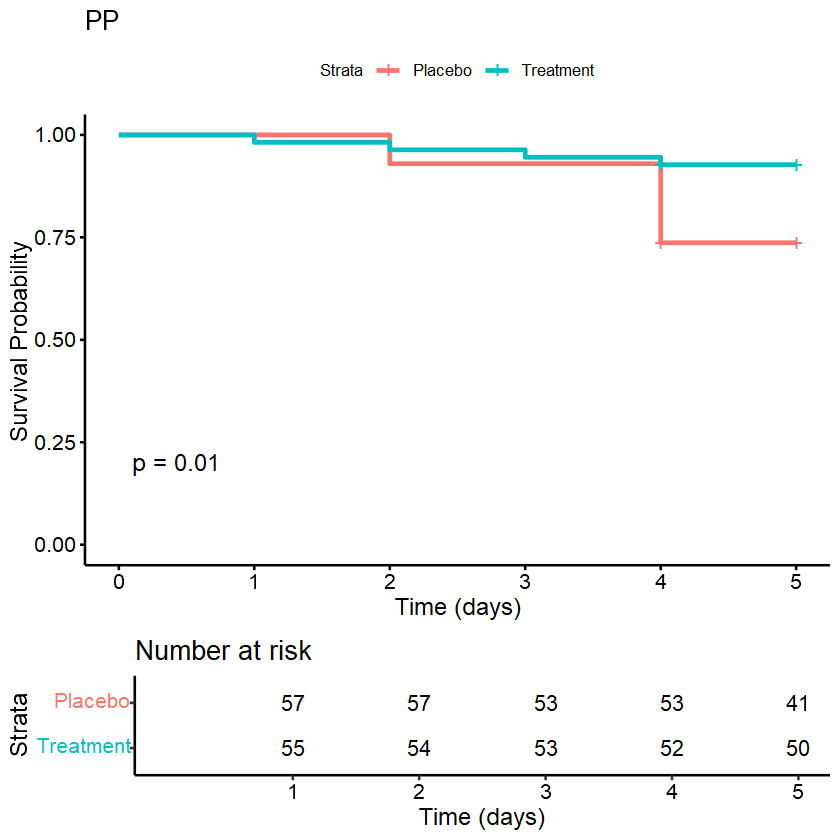

In [50]:
# Proportional hazard test for our variables of interest
surv_TF<-Surv(data_dint$Dia_TF, data_dint$TreatmentFailureMan) 
cox_model <- coxph(surv_TF~ Grupo, data= data_dint)

# Test proportional hazards assumption
ph_test <- cox.zph(cox_model)

# Print the results
print(ph_test)

#Log rank test
fit <- survfit(surv_TF ~ Grupo, data = data_dint)
ggsurvplot(fit, data = data_dint, pval = TRUE, conf.int = FALSE,
           risk.table = TRUE, legend.labs = c("Placebo", "Treatment"),
           xlab = "Time (days)", ylab = "Survival Probability",title="PP")


In [51]:
#Model
vars_to_expl <- list(c("Dia_TF","TreatmentFailureMan"),
                    c("tiempo_estancia","StayHosp"),
                     c("EvolDiasUCI","UCI_event"),
                     c("EstabClin","EstabClin_event"))
other_variables<-c("IL101","PCT1","CdxShockSept","Centro","YearOfAdmission")
cox_results<-cox(imp,vars_to_expl)$get_cox_results(main_var="Grupo", other_variables=other_variables)#, interraction_terms=c("comorbidity"))
cox_results

Time,Event,HR_CI_not_adjusted,p_value_1,HR_CI_adjusted,p_value_2,ph_test_p_value,ph_test_verdict
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Dia_TF,TreatmentFailureMan x 1,0.26 (0.08 - 0.85),0.02783819,0.19 (0.03 - 1.45),0.08000866,0.198,PH assumption met
tiempo_estancia,StayHosp x 1,1.01 (0.69 - 1.48),0.95942041,1 (0.65 - 1.53),0.99434212,0.487,PH assumption met
EvolDiasUCI,UCI_event x 1,1.28 (0.62 - 2.64),0.49843799,0.92 (0.31 - 2.7),0.86879312,0.315,PH assumption met
EstabClin,EstabClin_event x 1,1.03 (0.68 - 1.56),0.87708935,1.21 (0.75 - 1.95),0.42060105,0.084,PH assumption met


In [52]:
# Generate summaries
sheet1 <- summary_num_by_group(data_dint_explcit, "Grupo")
sheet2 <- summary_cat_by_group(data_dint_explcit, "Grupo")
# Comparison tests
sheet3 <- compare_var_num(data_dint,"Grupo")
sheet4<-compare_proportions(data_dint, c("TreatmentFailureMan",
                                "EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS","EvolMort28"),
                                 "Grupo")
sheet5 <- compare_var_cat(data_dint,"Grupo")
sheet6 <- logit_results
sheet7<-cox_results

# Create a new Excel workbook
wb <- createWorkbook()

# Add numerical summary
addWorksheet(wb, "NumericalSummary")
writeData(wb, "NumericalSummary", sheet1)

# Add categorical summary
addWorksheet(wb, "CategoricalSummary")
writeData(wb, "CategoricalSummary", sheet2)

# Add numerical test
addWorksheet(wb, "NumericalTests1")
writeData(wb, "NumericalTests1", sheet3)
addWorksheet(wb, "NumericalTests2")
writeData(wb, "NumericalTests2", sheet4)

# Add categorical test
addWorksheet(wb, "CategoricalTests")
writeData(wb, "CategoricalTests", sheet5)

# Add logistic regression
addWorksheet(wb, "logit")
writeData(wb, "logit", sheet6)

# Add cox model
addWorksheet(wb, "cox")
writeData(wb, "cox", sheet7)
# Save the Excel file
saveWorkbook(wb, "./results/tables/Summary_of_analysises_torress_PP.xlsx", overwrite = TRUE)